In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
np.random.seed(42)

# 1B

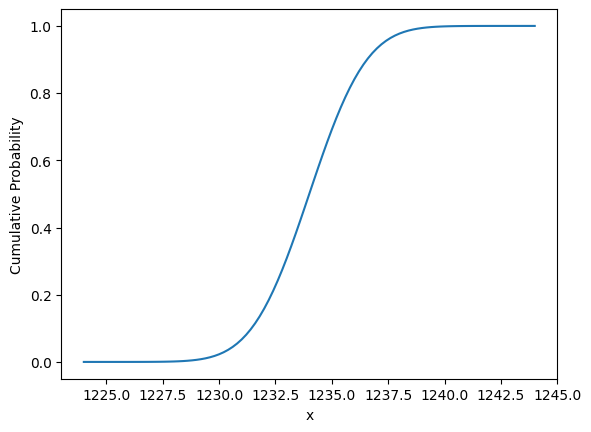

In [2]:
results=[]
mid=1234
std=2
sp=np.linspace(-5,5,101)
xlist=[mid+std*i for i in sp]
for x in xlist:
    result=stats.norm.cdf(x,loc=mid,scale=std)
    results.append(result)
fig,ax=plt.subplots(1,1)
ax.plot(xlist,results); #sigma vs cdf plot
ax.set_xlabel("x");
ax.set_ylabel("Cumulative Probability");

# 1C

In [3]:
print(f"The cdf at 1,2, and 5 sigma are: {results[60]:.3f}, {results[70]:.4f}, {results[100]:.7f}") #cdf at 1,2,5 sigma
print(f"The x at 1,2, and 5 sigma are: {xlist[60]:.0f}, {xlist[70]:.0f}, {xlist[100]:.0f}") #x at 1,2,5 sigma

The cdf at 1,2, and 5 sigma are: 0.841, 0.9772, 0.9999997
The x at 1,2, and 5 sigma are: 1236, 1238, 1244


In [4]:
print(stats.norm.ppf(0.841,loc=mid,scale=std)) #1 Sigma
print(stats.norm.ppf(0.9772,loc=mid,scale=std)) #2 Sigma
print(stats.norm.ppf(0.9999997,loc=mid,scale=std)) #5 Sigma

1235.9971525412313
1237.9981544299435
1243.9824342798759


The values from ppf is very close to the values from my initial values.

# 2B

In [5]:
gamma=stats.gamma.rvs(a=4,loc=mid,scale=std,size=100000)

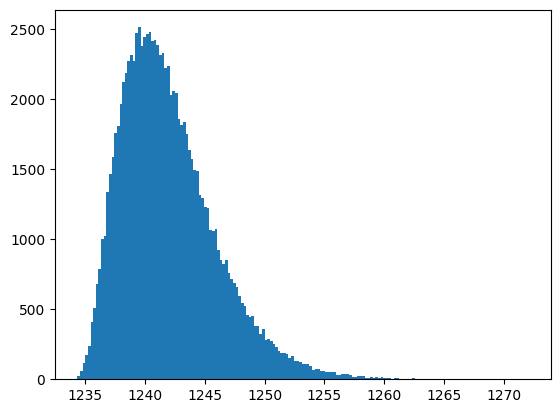

In [6]:
plt.hist(gamma,bins="fd");

# 3A
Let's pick the x value of the measurement to be 1254 (1234+20).

# 3B
What is the chance that the background gamma distribution produces the measurement at $x \ge 1254$? \
And, what is the corresponding z-value in terms of $\sigma$?

# 3C
Since The measurement is on the right tail of the distribution, the integral should be from 1254 to $\infty$ \
But, CDF function integrates from 0 to 1254. So, we have to use 1-CDF since 1 equals to the integral from 0 to $\infty$
$$P(x \ge 1254) = \int_{x=1254}^{\infty} P(x) dx = 1 - \int_{x=0}^{1254} P(x) dx$$

# 3D

In [7]:
measure=1254
CDF=stats.gamma.cdf(measure,a=4,loc=mid,scale=std)
print(f"The chance is {1-CDF:.6f}")

The chance is 0.010336


So, around 4.2 percent the background can be this measurement

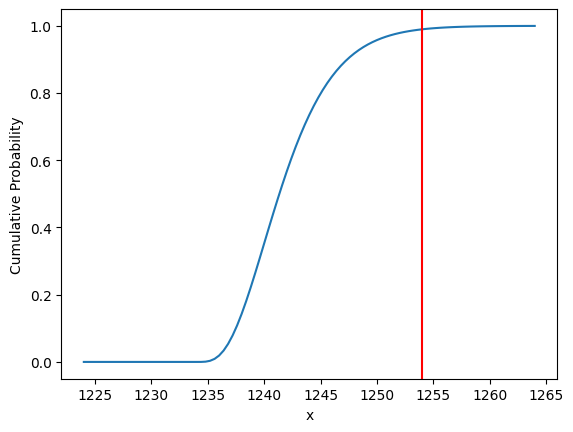

In [8]:
sp2=np.linspace(-5,15,101)
xlist=[mid+std*i for i in sp2]
reslist=[]
for x in xlist:
    res=stats.gamma.cdf(x,a=4,loc=mid,scale=std)
    reslist.append(res)
fig,ax=plt.subplots(1,1)
ax.plot(xlist,reslist); #sigma vs cdf plot
ax.set_xlabel("x");
ax.set_ylabel("Cumulative Probability");
ax.axvline(x=measure,color='r')

# 3E
Since 1250 is on the right side of the tail, CDF is going to be used for Gaussian PPF

In [9]:
sig=stats.norm.ppf(CDF)
print(f"The equivalent sigma is {sig:.3f}")

The equivalent sigma is 2.314


# 4

In [10]:
def sigfinder(x):
    return stats.norm.ppf(stats.gamma.cdf(x,a=4,loc=mid,scale=std))

In [11]:
xlin=np.linspace(1244,1264,11)

Text(0, 0.5, 'Equivalent Sigma')

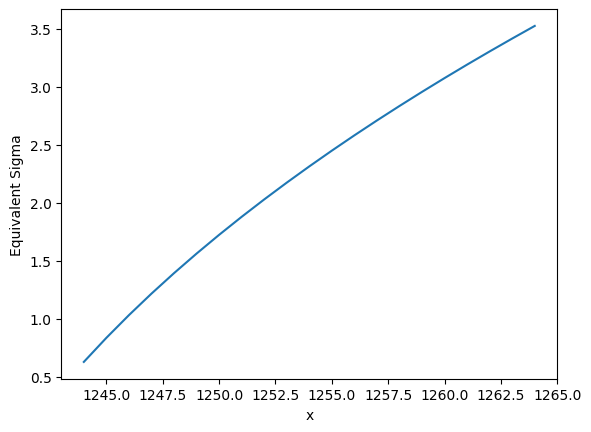

In [12]:
xlin=np.linspace(1244,1264,21)
plt.plot(xlin,sigfinder(xlin))
plt.xlabel("x")
plt.ylabel("Equivalent Sigma")

The plot is a bit curved, which says that the sigma and distance do not have linear relationship, \
If the distance between x and loc is 2 times that the other one, it does not result in 2 times the z-value (not Gaussian).

# Non-continuous distributions

In [13]:
clrlist=['r','g','b','k','m']
nlist=[100,200,300,400,500]
plist=[0.1,0.25,0.5,0.75,0.9]

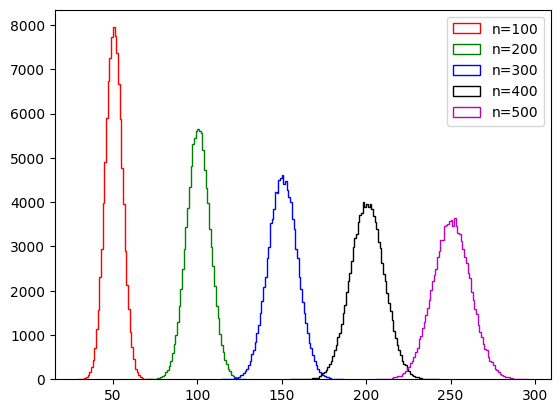

In [14]:
#B
for n,c in zip(nlist,clrlist):
    bino=stats.binom.rvs(n=n,p=0.5,size=100000)
    plt.hist(bino,bins='fd',color=c,label=f"n={n}",histtype='step')
plt.legend()

n inside binomial distribution determines the range of x-axis. \
(The histogram peak is shorter as n increases since more x value is possible but still has the same average probability)

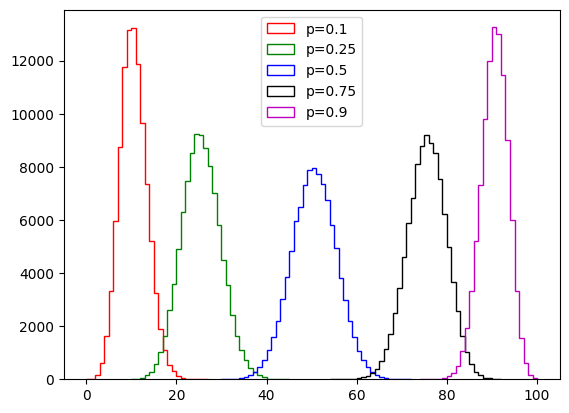

In [15]:
for p,c in zip(plist,clrlist):
    bino=stats.binom.rvs(n=100,p=p,size=100000)
    plt.hist(bino,bins='fd',color=c,label=f"p={p}",histtype='step')
plt.legend()

p inside binomial distribution determines the x-axis location of the distribution. \
(p=0.5 is the widest distribution in the plot)

# C
If we are flipping a coin 100 times, with the probability of heads being 0.25, what is the chance of getting 35 or more heads?

In [16]:
coin=35
BINOM=stats.binom.cdf(coin,n=100,p=0.25)
print(f"The chance is {1-BINOM:.6f}")

The chance is 0.009407


# D

In [17]:
sigm=stats.norm.ppf(BINOM)
print(f"The equivalent sigma is {sigm:.3f}")

The equivalent sigma is 2.349


Text(0, 0.5, 'Equivalent Sigma')

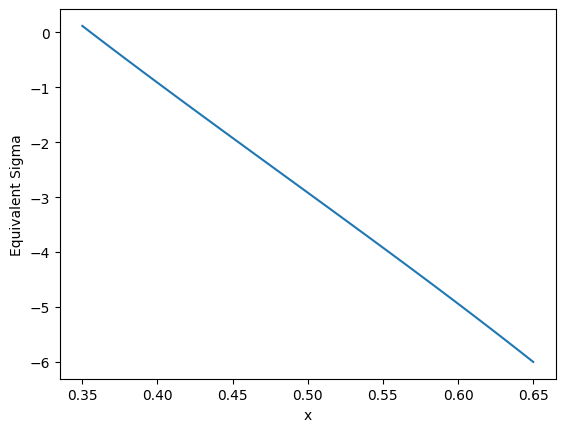

In [18]:
xl=np.linspace(0.35,0.65,31)
plt.plot(xl,stats.norm.ppf(stats.binom.cdf(coin,n=100,p=xl)))
plt.xlabel("x")
plt.ylabel("Equivalent Sigma")

This plot is also slightly curved, meaning that it is not Gaussian. \
The z-value tells us about the probability, but does not tell if the distribution is Gaussian.

# E

It makes sense that the mean of Poission distribution is 9.2, since 9.2 comes from the average of integers (Sum and divide by size) \
An example is that there are 9,9,9,10,9 gamma-rays. This would result in the mean of 9.2 gamma-rays. \
What changes continuously are the mean and probability. \
If new measurement is 9, The mean becomes 9.166, it is now more likely to measure 9 than when the mean is 9.2. \
What did not change continuously are the measurements (still discrete).